In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv("train (1).csv")
df.tail()

,1.126727,47.743884
64,-1.500082,414.076341
65,0.493507,-34.616994
66,1.725494,573.001536
67,0.872540,18.485251
68,0.725811,-16.120312


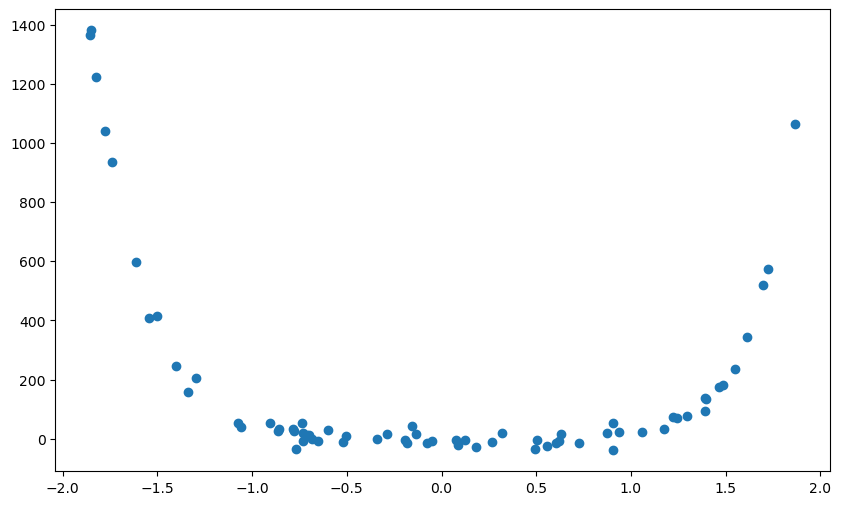

In [7]:
plt.figure(figsize=(10,6))
plt.scatter(df.iloc[:, 0], df.iloc[:, 1])
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

x = df.iloc[:,0].values
y = df.iloc[:,1].values

# scaling
#x = (x - np.mean(x))/np.std(x)

# random split
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)
D = []
L = []
IT = []
E = []
for d in range(4, 12):
    X = np.column_stack([x_train**j for j in range(d+1)])
    Xt = np.column_stack([x_test**j for j in range(d+1)])
    for l in np.linspace(1e-5, 1e-3, 20):
        for iterations in (500,5000):
            A = np.zeros(d+1)
            for _ in range(iterations):
                A = A - l * (X.T @ (X @ A - y_train))/len(x_train)
            y_pred = Xt @ A
            error = np.mean((y_pred - y_test)**2)
            D.append(d)
            L.append(l)
            IT.append(iterations)
            E.append(error)

index = E.index(min(E))

print("Best degree:", D[index])
print("Best learning rate:", L[index])
print("Best iterations:", IT[index])
print("Minimum MSE:", E[index])
print (len(D))

C:\Users\Kushagra pant\AppData\Local\Temp\ipykernel_30296\599700875.py:26: RuntimeWarning: overflow encountered in matmul
  A = A - l * (X.T @ (X @ A - y_train))/len(x_train)
C:\Users\Kushagra pant\AppData\Local\Temp\ipykernel_30296\599700875.py:26: RuntimeWarning: invalid value encountered in matmul
  A = A - l * (X.T @ (X @ A - y_train))/len(x_train)
C:\Users\Kushagra pant\AppData\Local\Temp\ipykernel_30296\599700875.py:26: RuntimeWarning: invalid value encountered in subtract
  A = A - l * (X.T @ (X @ A - y_train))/len(x_train)
C:\Users\Kushagra pant\AppData\Local\Temp\ipykernel_30296\599700875.py:28: RuntimeWarning: overflow encountered in square
  error = np.mean((y_pred - y_test)**2)


Best degree: 9
Best learning rate: 6.210526315789474e-05
Best iterations: 5000
Minimum MSE: 165.8028150715122
320


In [9]:
lr=1e-5
d=D[index]
iterations=IT[index]
X = np.column_stack([x**j for j in range(d+1)])
A = np.zeros(d+1)
for i in range(iterations):
    A = A - lr * (X.T @ (X @ A - y))/len(x)

In [10]:
dt=pd.read_csv("test.csv")
dt.sample()

,-1.819228,1255.525442
13,1.268822,45.380066


In [11]:
X_test= np.column_stack([dt.iloc[:,0].values**j for j in range(d+1)])
y_pred = X_test @ A
yt=dt.iloc[:,1].values
mse=np.mean((y_pred - yt)**2)
print("MSE on test set:", mse)

MSE on test set: 1041.1736814834492


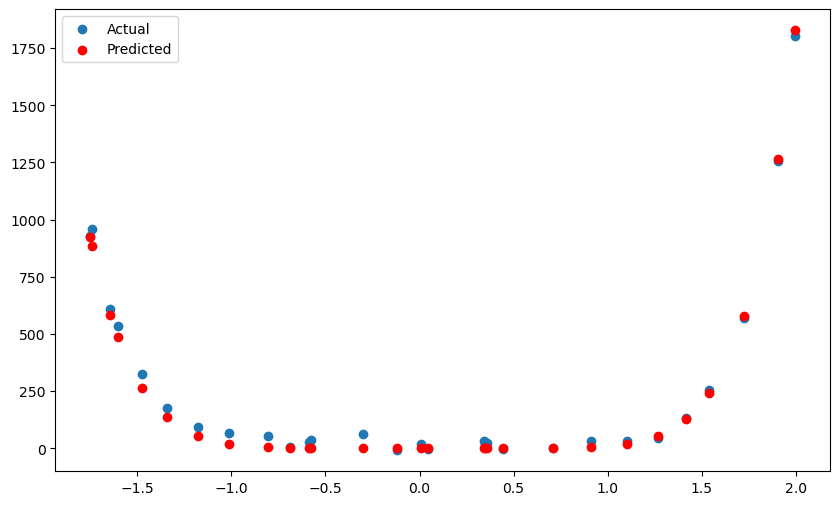

In [12]:
plt.figure(figsize=(10,6))
plt.scatter(dt.iloc[:, 0], dt.iloc[:, 1], label='Actual')
plt.scatter(dt.iloc[:, 0], y_pred, label='Predicted', color='red')
plt.legend()
plt.show()

In [13]:
indices = np.arange(len(df))
np.random.shuffle(indices)
train_idx, val_idx = indices[:int(0.8*len(df))], indices[int(0.8*len(df)):]
x_train, y_train = df.iloc[train_idx, 0].values, df.iloc[train_idx, 1].values
x_val, y_val = df.iloc[val_idx, 0].values, df.iloc[val_idx, 1].values

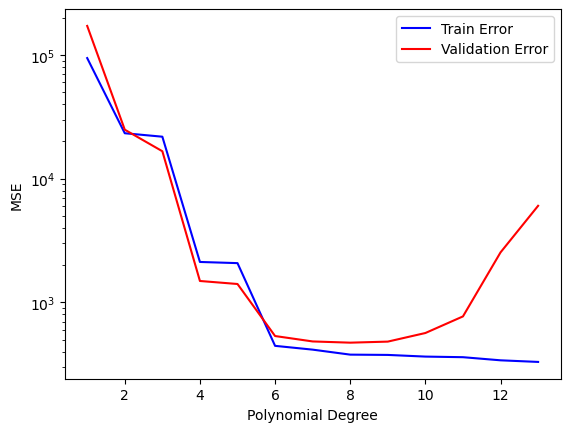

In [14]:
#Validation curves for polynomial degrees 1 to 14
degrees = range(1, 14)
train_errs, val_errs, test_errs = [], [], []

for d in degrees:
    X_train=np.column_stack([x_train**i for i in range(0, d+1)])
    X_val=np.column_stack([x_val**i for i in range(0, d+1)])
    A=np.linalg.pinv(X_train) @ y_train
    #Calculating MSE for train and validation sets
    train_errs.append(np.mean((X_train @ A - y_train)**2))
    val_errs.append(np.mean((X_val @ A - y_val)**2))



plt.plot(degrees, train_errs, label='Train Error', color='blue')
plt.plot(degrees, val_errs, label='Validation Error', color='red')
plt.yscale('log')
plt.xlabel('Polynomial Degree'), plt.ylabel('MSE'), plt.legend()
plt.show()

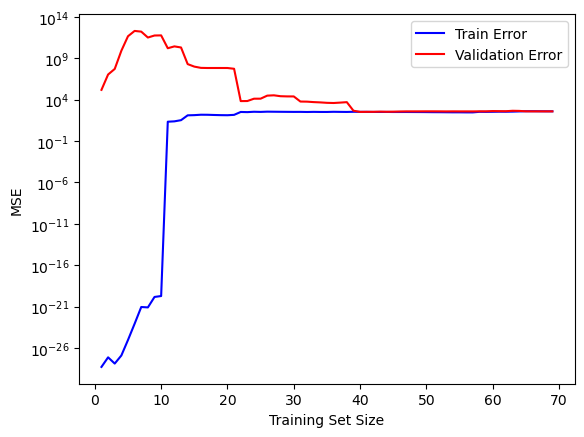

In [16]:
#Learning curves for the best degree
best_degree = 9
train_errs, val_errs = [], []
for m in range(1, len(x)+1):
    X_train=np.column_stack([x[:m]**i for i in range(0, best_degree+1)])
    X_val=np.column_stack([x_val**i for i in range(0, best_degree+1)])
    A=np.linalg.pinv(X_train) @ y[:m]
    train_errs.append(np.mean((X_train @ A - y[:m])**2))
    val_errs.append(np.mean((X_val @ A - y_val)**2))
plt.plot(range(1, len(x)+1), train_errs, label='Train Error', color='blue')
plt.plot(range(1, len(x)+1), val_errs, label='Validation Error', color='red')
plt.yscale('log')
plt.xlabel('Training Set Size'), plt.ylabel('MSE'), plt.legend()
plt.show()
